# Estudio de que tipo de Data Augmentation con ResNet-50 funciona mejor para HAM10000



 **IMPORTANTE:** Ejecutar en Google Colab con GPU (Runtime → Change runtime type → A100 GPU) o con A100 de Colab Pro para más rápidez

---

### Objetivo
Comparación sistemática de 3 niveles de Data Augmentation sobre ResNet-50:
1. **Mínima** — Solo flips horizontales y verticales
2. **Suave** — Flips + rotación 30° + ColorJitter + Affine
3. **Agresiva** — Todo lo anterior + Perspective + GaussianBlur + RandomErasing

Se evalúa el impacto en accuracy, F1, recall y especialmente en la detección de melanoma.

---
## 1. Configuración y Carga de Datos

In [1]:
# ============================================
# MONTAJE DE DRIVE Y CONFIGURACIÓN GENERAL
# ============================================
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/HAM10000'
IMG_PART1 = f'{BASE_PATH}/HAM10000_images_part_1'
IMG_PART2 = f'{BASE_PATH}/HAM10000_images_part_2'
METADATA_PATH = f'{BASE_PATH}/ham10000_metadata_clean.csv'

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, roc_auc_score, roc_curve, auc,
    precision_score, recall_score
)
from sklearn.preprocessing import label_binarize
import time
import copy

# Reproducibilidad
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memoria: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Mounted at /content/drive
Dispositivo: cuda
GPU: NVIDIA A100-SXM4-40GB
Memoria: 42.4 GB


In [2]:
# ============================================
# COPIAR IMÁGENES A DISCO LOCAL (más rápido)
# ============================================
import shutil
LOCAL_PATH = '/content/HAM10000'
os.makedirs(LOCAL_PATH, exist_ok=True)

if not os.path.exists(f'{LOCAL_PATH}/images_done.flag'):
    for folder in ['HAM10000_images_part_1', 'HAM10000_images_part_2']:
        src = f'{BASE_PATH}/{folder}'
        dst = f'{LOCAL_PATH}/{folder}'
        shutil.copytree(src, dst)
    shutil.copy(f'{BASE_PATH}/ham10000_metadata_clean.csv', f'{LOCAL_PATH}/')
    open(f'{LOCAL_PATH}/images_done.flag', 'w').close()
    print('Imágenes copiadas a disco local.')
else:
    print('Ya copiadas.')

IMG_PART1 = f'{LOCAL_PATH}/HAM10000_images_part_1'
METADATA_PATH = f'{LOCAL_PATH}/ham10000_metadata_clean.csv'

Imágenes copiadas a disco local.


In [3]:
# ============================================
# CARGAR METADATA + CONSTANTES
# ============================================
df = pd.read_csv(METADATA_PATH)
df['image_path'] = df['image_path'].str.replace('/content/drive/MyDrive/HAM10000', LOCAL_PATH)
print(f'Dataset: {len(df)} imágenes, {df["dx"].nunique()} clases')
print(f'Splits: {df["split"].value_counts().to_dict()}')

# Constantes
IMG_SIZE = 224
NUM_CLASSES = 7
BATCH_SIZE = 64  # Aprovechamos la A100

CLASS_NAMES = {
    'nv': 'Melanocytic nevi', 'mel': 'Melanoma',
    'bkl': 'Benign keratosis', 'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses', 'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}
CLASS_COLORS = {
    'nv': 'steelblue', 'mel': 'crimson', 'bkl': 'teal',
    'bcc': 'darkorange', 'akiec': 'mediumpurple',
    'vasc': 'forestgreen', 'df': 'goldenrod'
}
class_to_idx = {cls: i for i, cls in enumerate(sorted(CLASS_NAMES.keys()))}
idx_to_class = {i: cls for cls, i in class_to_idx.items()}

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print(f'Mapeo de clases: {class_to_idx}')

Dataset: 10015 imágenes, 7 clases
Splits: {'train': 7002, 'test': 1508, 'val': 1505}
Mapeo de clases: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


---
## 2. Dataset, Sampler y Funciones

In [4]:
# ============================================
# DATASET
# ============================================
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        label = class_to_idx[row['dx']]
        if self.transform:
            img = self.transform(img)
        return img, label

# ============================================
# WEIGHTED SAMPLER
# ============================================
train_labels = [class_to_idx[dx] for dx in df[df['split']=='train']['dx']]
class_counts_train = Counter(train_labels)
total = sum(class_counts_train.values())
class_weights = {cls: total / count for cls, count in class_counts_train.items()}
sample_weights = [class_weights[label] for label in train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print(f'Sampler: {len(sample_weights)} muestras')
for cls_idx, weight in sorted(class_weights.items()):
    print(f'  {idx_to_class[cls_idx]:6s}: {weight:.2f}x')

Sampler: 7002 muestras
  akiec : 30.44x
  bcc   : 19.13x
  bkl   : 9.05x
  df    : 92.13x
  mel   : 9.00x
  nv    : 1.50x
  vasc  : 70.73x


In [5]:
# ============================================
# FUNCIÓN DE ENTRENAMIENTO CON EARLY STOPPING
# ============================================
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                num_epochs=30, patience=7, model_name='model'):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    best_epoch = 0

    print(f'\n{"="*60}')
    print(f'  Entrenando: {model_name}')
    print(f'{"="*60}')

    for epoch in range(num_epochs):
        start = time.time()

        # --- TRAIN ---
        model.train()
        running_loss, correct, total_samples = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        train_loss = running_loss / total_samples
        train_acc = correct / total_samples

        # --- VALIDATION ---
        model.eval()
        running_loss, correct, total_samples = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total_samples += labels.size(0)

        val_loss = running_loss / total_samples
        val_acc = correct / total_samples

        # Scheduler step (compatible con cualquier scheduler)
        if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        elif scheduler:
            scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        elapsed = time.time() - start
        print(f'Epoch {epoch+1:02d}/{num_epochs} | '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | '
              f'{elapsed:.1f}s', end='')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            best_epoch = epoch + 1
            print(' \u2605 Mejor modelo guardado')
        else:
            epochs_no_improve += 1
            print(f' (sin mejora: {epochs_no_improve}/{patience})')
            if epochs_no_improve >= patience:
                print(f'\n\u2192 Early stopping en epoch {epoch+1}. Mejor epoch: {best_epoch}')
                break

    model.load_state_dict(best_model_wts)
    return model, history, best_epoch

In [6]:
# ============================================
# FUNCIÓN DE EVALUACIÓN EN TEST
# ============================================
def evaluate_model(model, test_loader, model_name='model'):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    f1_w = f1_score(all_labels, all_preds, average='weighted')
    f1_m = f1_score(all_labels, all_preds, average='macro')
    precision_w = precision_score(all_labels, all_preds, average='weighted')
    recall_w = recall_score(all_labels, all_preds, average='weighted')

    labels_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))
    try:
        auc_ovr = roc_auc_score(labels_bin, all_probs, average='weighted', multi_class='ovr')
    except:
        auc_ovr = float('nan')

    target_names = [f'{idx_to_class[i]} ({CLASS_NAMES[idx_to_class[i]]})' for i in range(NUM_CLASSES)]
    report_dict = classification_report(all_labels, all_preds, target_names=target_names, output_dict=True)

    print(f'\n{"="*60}')
    print(f'  Resultados en TEST: {model_name}')
    print(f'{"="*60}')
    print(f'Accuracy:           {acc:.4f}')
    print(f'F1-Score (weighted): {f1_w:.4f}')
    print(f'F1-Score (macro):    {f1_m:.4f}')
    print(f'Precision (weighted):{precision_w:.4f}')
    print(f'Recall (weighted):   {recall_w:.4f}')
    print(f'AUC-ROC (weighted):  {auc_ovr:.4f}')
    print(f'\n{classification_report(all_labels, all_preds, target_names=target_names)}')

    # Report por clase con nombres cortos (para gráficos)
    class_report = {}
    for i in range(NUM_CLASSES):
        cls_short = idx_to_class[i]
        cls_full = target_names[i]
        class_report[cls_short] = report_dict[cls_full]

    metrics = {
        'accuracy': acc, 'f1_weighted': f1_w, 'f1_macro': f1_m,
        'precision_weighted': precision_w, 'recall_weighted': recall_w,
        'auc_roc': auc_ovr, 'class_report': class_report
    }
    return all_labels, all_preds, all_probs, metrics

---
## 3. Definición de los 3 niveles de Augmentation

In [7]:
# ============================================
# 3 NIVELES DE DATA AUGMENTATION
# ============================================

# Transforms de validación/test (siempre igual)
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

augmentation_levels = {
    'minima': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ]),
    'suave': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=30),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ]),
    'agresiva': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=90),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.8, 1.2)),
        transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        transforms.RandomErasing(p=0.3, scale=(0.02, 0.15))
    ])
}

print('Niveles de augmentation definidos:')
for name, t in augmentation_levels.items():
    print(f'  {name}: {len(t.transforms)} transformaciones')

Niveles de augmentation definidos:
  minima: 5 transformaciones
  suave: 8 transformaciones
  agresiva: 11 transformaciones


---
## 4. Función de entrenamiento completo de ResNet-50

In [8]:
# ============================================
# ENTRENAR RESNET-50 COMPLETO (FASE 1 + FASE 2)
# ============================================
def train_resnet50_full(aug_name, train_transform):
    print(f'\n{"#"*70}')
    print(f'###  AUGMENTATION: {aug_name.upper()}')
    print(f'{"#"*70}')

    # --- Dataloaders ---
    train_dataset = HAM10000Dataset(df[df['split']=='train'], transform=train_transform)
    val_dataset = HAM10000Dataset(df[df['split']=='val'], transform=val_test_transforms)
    test_dataset = HAM10000Dataset(df[df['split']=='test'], transform=val_test_transforms)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                              num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=4, pin_memory=True)

    # === FASE 1: Feature Extraction ===
    print('\n--- FASE 1: Feature Extraction (backbone congelado) ---')
    resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    for param in resnet.parameters():
        param.requires_grad = False

    num_ftrs = resnet.fc.in_features
    resnet.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_ftrs, 512),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(512, NUM_CLASSES)
    )
    resnet = resnet.to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(resnet.fc.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

    trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
    print(f'Par\u00e1metros entrenables Fase 1: {trainable:,}')

    resnet, history_p1, _ = train_model(
        resnet, train_loader, val_loader, criterion, optimizer, scheduler,
        num_epochs=20, patience=7, model_name=f'ResNet-50 [{aug_name}] (Fase 1)'
    )

    # === FASE 2: Fine-Tuning ===
    print('\n--- FASE 2: Fine-Tuning (layer3 + layer4 descongelados) ---')

    for param in resnet.layer3.parameters():
        param.requires_grad = True
    for param in resnet.layer4.parameters():
        param.requires_grad = True

    optimizer = optim.Adam([
        {'params': resnet.layer3.parameters(), 'lr': 5e-6},
        {'params': resnet.layer4.parameters(), 'lr': 1e-5},
        {'params': resnet.fc.parameters(), 'lr': 1e-4}
    ])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-7)

    trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
    print(f'Par\u00e1metros entrenables Fase 2: {trainable:,}')

    resnet, history_p2, _ = train_model(
        resnet, train_loader, val_loader, criterion, optimizer, scheduler,
        num_epochs=40, patience=10, model_name=f'ResNet-50 [{aug_name}] (Fase 2)'
    )

    # Combinar historiales
    history = {k: history_p1[k] + history_p2[k] for k in history_p1}

    # === EVALUACI\u00d3N EN TEST ===
    labels, preds, probs, metrics = evaluate_model(
        resnet, test_loader, f'ResNet-50 [{aug_name}]'
    )

    # Guardar modelo
    save_name = f'resnet50_aug_{aug_name}.pth'
    torch.save(resnet.state_dict(), f'{BASE_PATH}/{save_name}')
    print(f'Modelo guardado: {save_name}')

    return {
        'model': resnet,
        'history': history,
        'labels': labels,
        'preds': preds,
        'probs': probs,
        'metrics': metrics
    }

print('Funci\u00f3n train_resnet50_full definida.')

Función train_resnet50_full definida.


---
## 5. Entrenar los 3 modelos

Tiempo estimado: ~45-60 minutos con A100 (3 modelos × ~15 min cada uno)

In [9]:
# ============================================
# ENTRENAR LOS 3 NIVELES
# ============================================
results = {}

for aug_name, train_transform in augmentation_levels.items():
    start_time = time.time()
    results[aug_name] = train_resnet50_full(aug_name, train_transform)
    elapsed = (time.time() - start_time) / 60
    print(f'\n>>> {aug_name.upper()} completado en {elapsed:.1f} minutos\n')

print('\n' + '='*60)
print('  TODOS LOS MODELOS ENTRENADOS')
print('='*60)


######################################################################
###  AUGMENTATION: MINIMA
######################################################################

--- FASE 1: Feature Extraction (backbone congelado) ---
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 173MB/s]


Parámetros entrenables Fase 1: 1,052,679

  Entrenando: ResNet-50 [minima] (Fase 1)
Epoch 01/20 | Train Loss: 1.3300 Acc: 0.5820 | Val Loss: 1.3951 Acc: 0.5508 | 21.2s ★ Mejor modelo guardado
Epoch 02/20 | Train Loss: 1.0833 Acc: 0.7072 | Val Loss: 1.2439 Acc: 0.6140 | 19.8s ★ Mejor modelo guardado
Epoch 03/20 | Train Loss: 1.0085 Acc: 0.7465 | Val Loss: 1.2462 Acc: 0.6233 | 19.6s (sin mejora: 1/7)
Epoch 04/20 | Train Loss: 0.9626 Acc: 0.7753 | Val Loss: 1.0722 Acc: 0.6983 | 19.6s ★ Mejor modelo guardado
Epoch 05/20 | Train Loss: 0.9093 Acc: 0.8015 | Val Loss: 1.0930 Acc: 0.6824 | 20.1s (sin mejora: 1/7)
Epoch 06/20 | Train Loss: 0.8937 Acc: 0.8102 | Val Loss: 1.0720 Acc: 0.7010 | 19.9s ★ Mejor modelo guardado
Epoch 07/20 | Train Loss: 0.8827 Acc: 0.8158 | Val Loss: 1.1568 Acc: 0.6392 | 19.7s (sin mejora: 1/7)
Epoch 08/20 | Train Loss: 0.8571 Acc: 0.8309 | Val Loss: 1.0886 Acc: 0.6957 | 19.8s (sin mejora: 2/7)
Epoch 09/20 | Train Loss: 0.8375 Acc: 0.8380 | Val Loss: 1.0567 Acc: 0.7229 

---
## 6. Resultados — Tabla comparativa global

In [10]:
# ============================================
# TABLA COMPARATIVA GLOBAL
# ============================================
comparison_data = []
for aug_name in ['minima', 'suave', 'agresiva']:
    m = results[aug_name]['metrics']
    comparison_data.append({
        'Augmentation': aug_name.capitalize(),
        'Accuracy': f"{m['accuracy']:.4f}",
        'F1 Weighted': f"{m['f1_weighted']:.4f}",
        'F1 Macro': f"{m['f1_macro']:.4f}",
        'Precision (w)': f"{m['precision_weighted']:.4f}",
        'Recall (w)': f"{m['recall_weighted']:.4f}",
        'AUC-ROC': f"{m['auc_roc']:.4f}"
    })

df_comparison = pd.DataFrame(comparison_data)
print('\n=== COMPARACI\u00d3N GLOBAL ===')
display(df_comparison)


=== COMPARACIÓN GLOBAL ===


,Augmentation,Accuracy,F1 Weighted,F1 Macro,Precision (w),Recall (w),AUC-ROC
0,Minima,0.7812,0.7863,0.5986,0.7964,0.7812,0.9324
1,Suave,0.7633,0.7771,0.6266,0.8032,0.7633,0.9240
2,Agresiva,0.7089,0.7316,0.5851,0.7825,0.7089,0.9146


## 7. Resultados — Tablas por clase

In [11]:
# ============================================
# TABLAS POR CLASE: PRECISION, RECALL, F1
# ============================================
class_names_sorted = sorted(CLASS_NAMES.keys())

for metric_name in ['precision', 'recall', 'f1-score']:
    print(f'\n=== {metric_name.upper()} POR CLASE ===')
    rows = []
    for cls in class_names_sorted:
        row = {'Clase': f'{cls} ({CLASS_NAMES[cls]})'}
        for aug_name in ['minima', 'suave', 'agresiva']:
            report = results[aug_name]['metrics']['class_report']
            row[aug_name.capitalize()] = f"{report[cls][metric_name]:.3f}"
        rows.append(row)
    display(pd.DataFrame(rows))
    print()


=== PRECISION POR CLASE ===


,Clase,Minima,Suave,Agresiva
0,akiec (Actinic keratoses),0.500,0.347,0.382
1,bcc (Basal cell carcinoma),0.557,0.557,0.536
2,bkl (Benign keratosis),0.611,0.528,0.449
3,df (Dermatofibroma),0.667,0.529,0.357
4,mel (Melanoma),0.474,0.500,0.400
5,nv (Melanocytic nevi),0.909,0.934,0.938
6,vasc (Vascular lesions),0.714,0.773,0.633




=== RECALL POR CLASE ===


,Clase,Minima,Suave,Agresiva
0,akiec (Actinic keratoses),0.545,0.773,0.659
1,bcc (Basal cell carcinoma),0.620,0.761,0.732
2,bkl (Benign keratosis),0.623,0.545,0.571
3,df (Dermatofibroma),0.250,0.562,0.625
4,mel (Melanoma),0.608,0.614,0.639
5,nv (Melanocytic nevi),0.865,0.823,0.740
6,vasc (Vascular lesions),0.652,0.739,0.826




=== F1-SCORE POR CLASE ===


,Clase,Minima,Suave,Agresiva
0,akiec (Actinic keratoses),0.522,0.479,0.483
1,bcc (Basal cell carcinoma),0.587,0.643,0.619
2,bkl (Benign keratosis),0.617,0.537,0.503
3,df (Dermatofibroma),0.364,0.545,0.455
4,mel (Melanoma),0.533,0.551,0.492
5,nv (Melanocytic nevi),0.886,0.875,0.827
6,vasc (Vascular lesions),0.682,0.756,0.717


---
## 8. Gráficos de comparación

In [12]:
# Colores
AUG_COLORS = {'minima': '#2196F3', 'suave': '#4CAF50', 'agresiva': '#F44336'}
NAVY = '#1a1a2e'
class_names_sorted = sorted(CLASS_NAMES.keys())

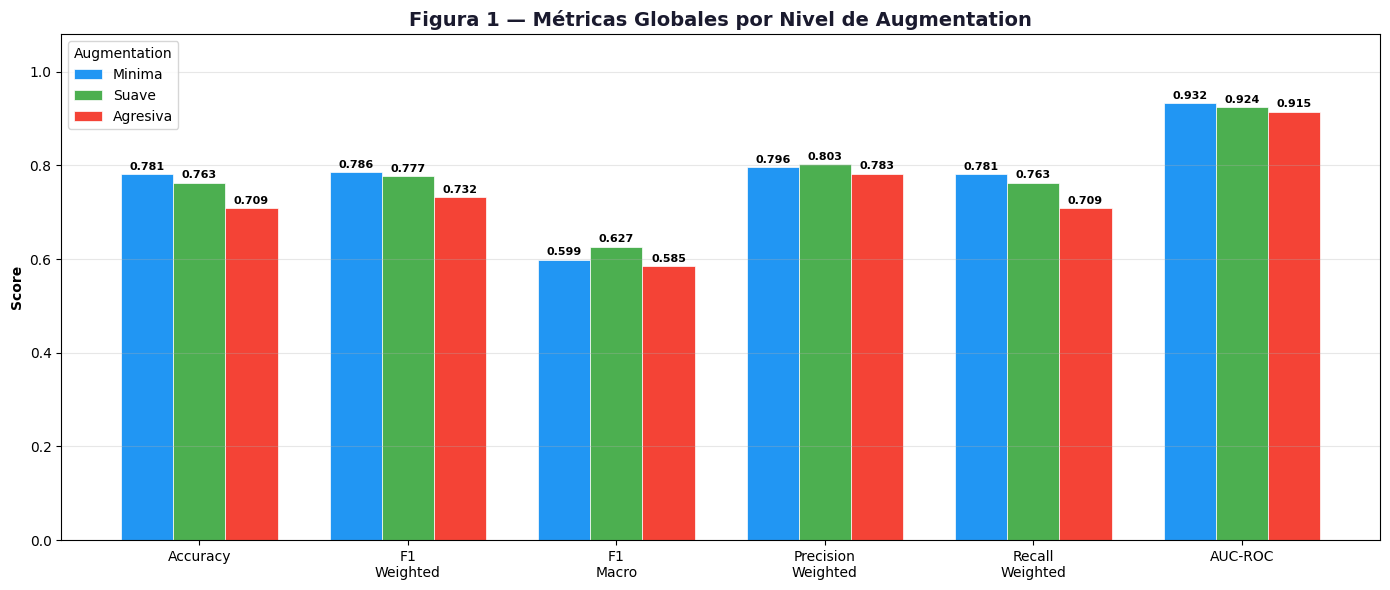

In [13]:
# ============================================
# FIGURA 1: MÉTRICAS GLOBALES
# ============================================
metrics_to_plot = ['accuracy', 'f1_weighted', 'f1_macro', 'precision_weighted', 'recall_weighted', 'auc_roc']
metric_labels = ['Accuracy', 'F1\nWeighted', 'F1\nMacro', 'Precision\nWeighted', 'Recall\nWeighted', 'AUC-ROC']

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(metrics_to_plot))
width = 0.25

for i, aug_name in enumerate(['minima', 'suave', 'agresiva']):
    values = [results[aug_name]['metrics'][m] for m in metrics_to_plot]
    bars = ax.bar(x + i*width, values, width, label=aug_name.capitalize(),
                  color=AUG_COLORS[aug_name], edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_ylabel('Score', fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels)
ax.legend(title='Augmentation')
ax.set_ylim(0, 1.08)
ax.grid(axis='y', alpha=0.3)
ax.set_title('Figura 1 \u2014 M\u00e9tricas Globales por Nivel de Augmentation',
             fontweight='bold', color=NAVY, fontsize=14)
plt.tight_layout()
plt.show()

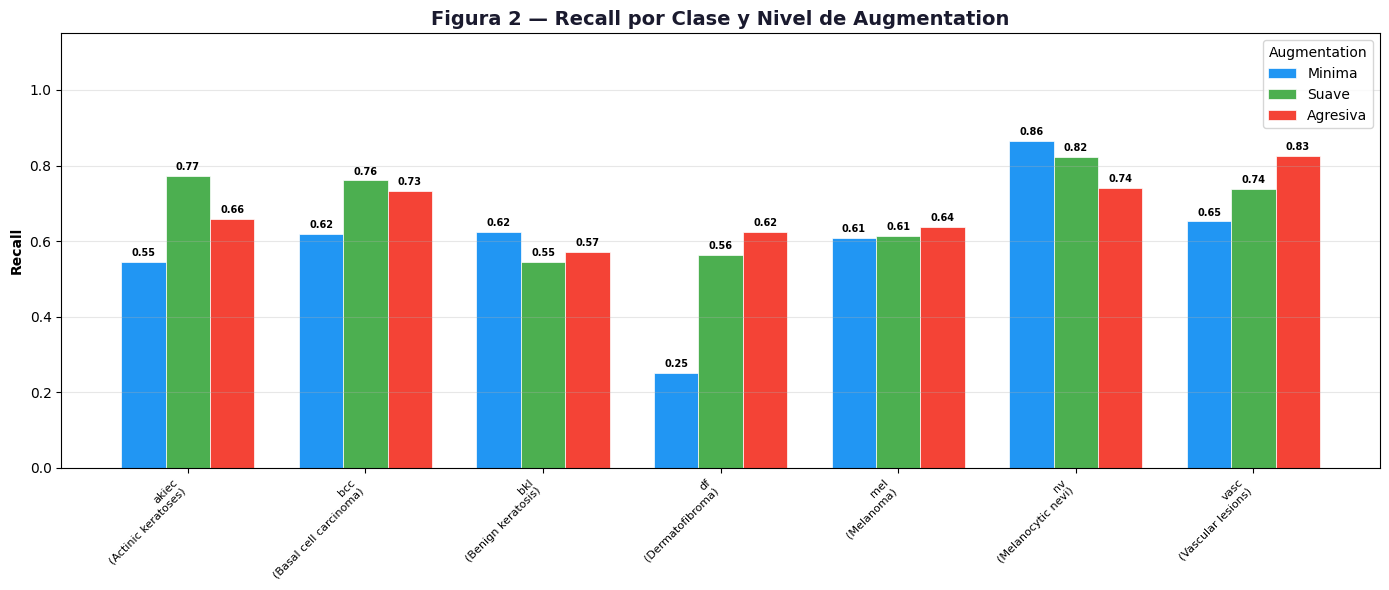

In [14]:
# ============================================
# FIGURA 2: RECALL POR CLASE
# ============================================
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(class_names_sorted))
width = 0.25

for i, aug_name in enumerate(['minima', 'suave', 'agresiva']):
    report = results[aug_name]['metrics']['class_report']
    values = [report[cls]['recall'] for cls in class_names_sorted]
    bars = ax.bar(x + i*width, values, width, label=aug_name.capitalize(),
                  color=AUG_COLORS[aug_name], edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_ylabel('Recall', fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels([f'{c}\n({CLASS_NAMES[c]})' for c in class_names_sorted], fontsize=8, rotation=45, ha='right')
ax.legend(title='Augmentation')
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)
ax.set_title('Figura 2 \u2014 Recall por Clase y Nivel de Augmentation',
             fontweight='bold', color=NAVY, fontsize=14)
plt.tight_layout()
plt.show()

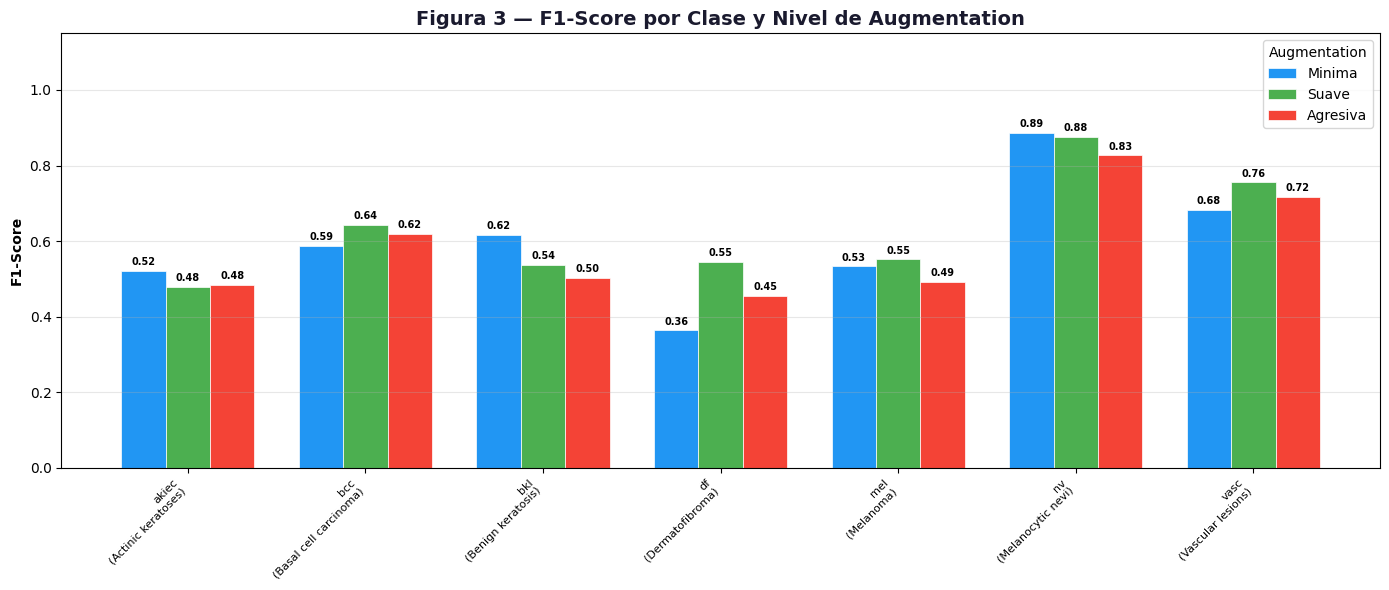

In [15]:
# ============================================
# FIGURA 3: F1-SCORE POR CLASE
# ============================================
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(class_names_sorted))
width = 0.25

for i, aug_name in enumerate(['minima', 'suave', 'agresiva']):
    report = results[aug_name]['metrics']['class_report']
    values = [report[cls]['f1-score'] for cls in class_names_sorted]
    bars = ax.bar(x + i*width, values, width, label=aug_name.capitalize(),
                  color=AUG_COLORS[aug_name], edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_ylabel('F1-Score', fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels([f'{c}\n({CLASS_NAMES[c]})' for c in class_names_sorted], fontsize=8, rotation=45, ha='right')
ax.legend(title='Augmentation')
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)
ax.set_title('Figura 3 \u2014 F1-Score por Clase y Nivel de Augmentation',
             fontweight='bold', color=NAVY, fontsize=14)
plt.tight_layout()
plt.show()

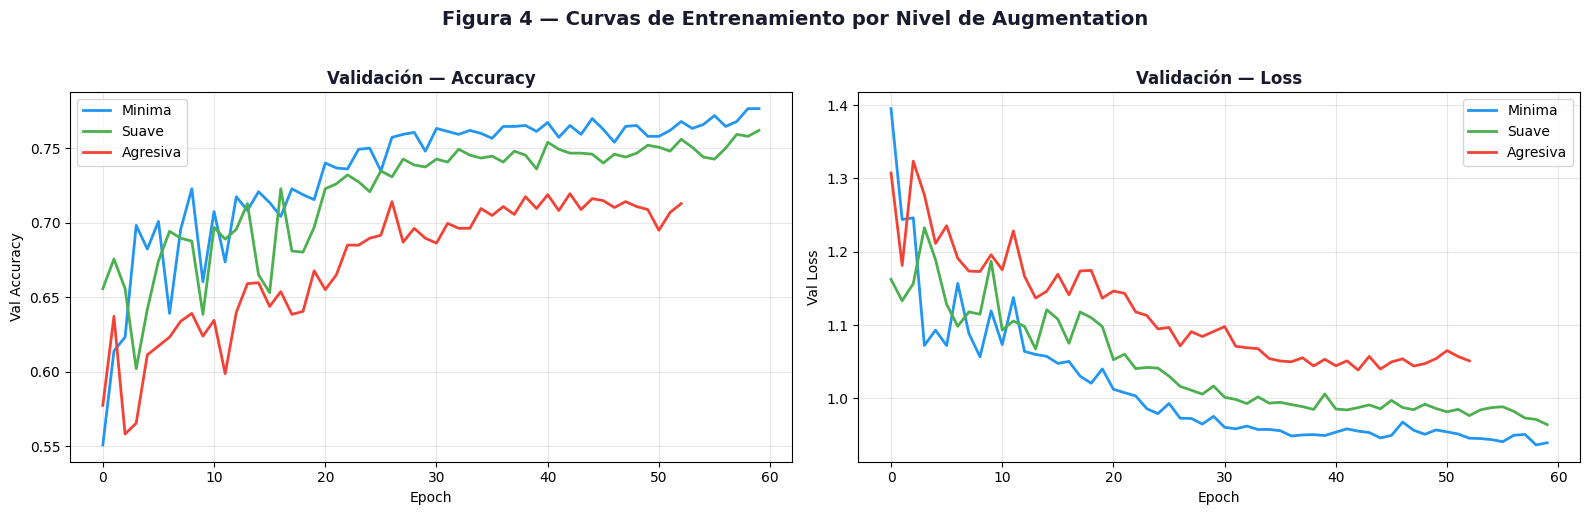

In [16]:
# ============================================
# FIGURA 4: CURVAS DE ENTRENAMIENTO
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for aug_name in ['minima', 'suave', 'agresiva']:
    history = results[aug_name]['history']
    axes[0].plot(history['val_acc'], label=aug_name.capitalize(),
                color=AUG_COLORS[aug_name], linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Val Accuracy')
axes[0].set_title('Validaci\u00f3n \u2014 Accuracy', fontweight='bold', color=NAVY)
axes[0].legend()
axes[0].grid(alpha=0.3)

for aug_name in ['minima', 'suave', 'agresiva']:
    history = results[aug_name]['history']
    axes[1].plot(history['val_loss'], label=aug_name.capitalize(),
                color=AUG_COLORS[aug_name], linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val Loss')
axes[1].set_title('Validaci\u00f3n \u2014 Loss', fontweight='bold', color=NAVY)
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle('Figura 4 \u2014 Curvas de Entrenamiento por Nivel de Augmentation',
             fontweight='bold', color=NAVY, fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

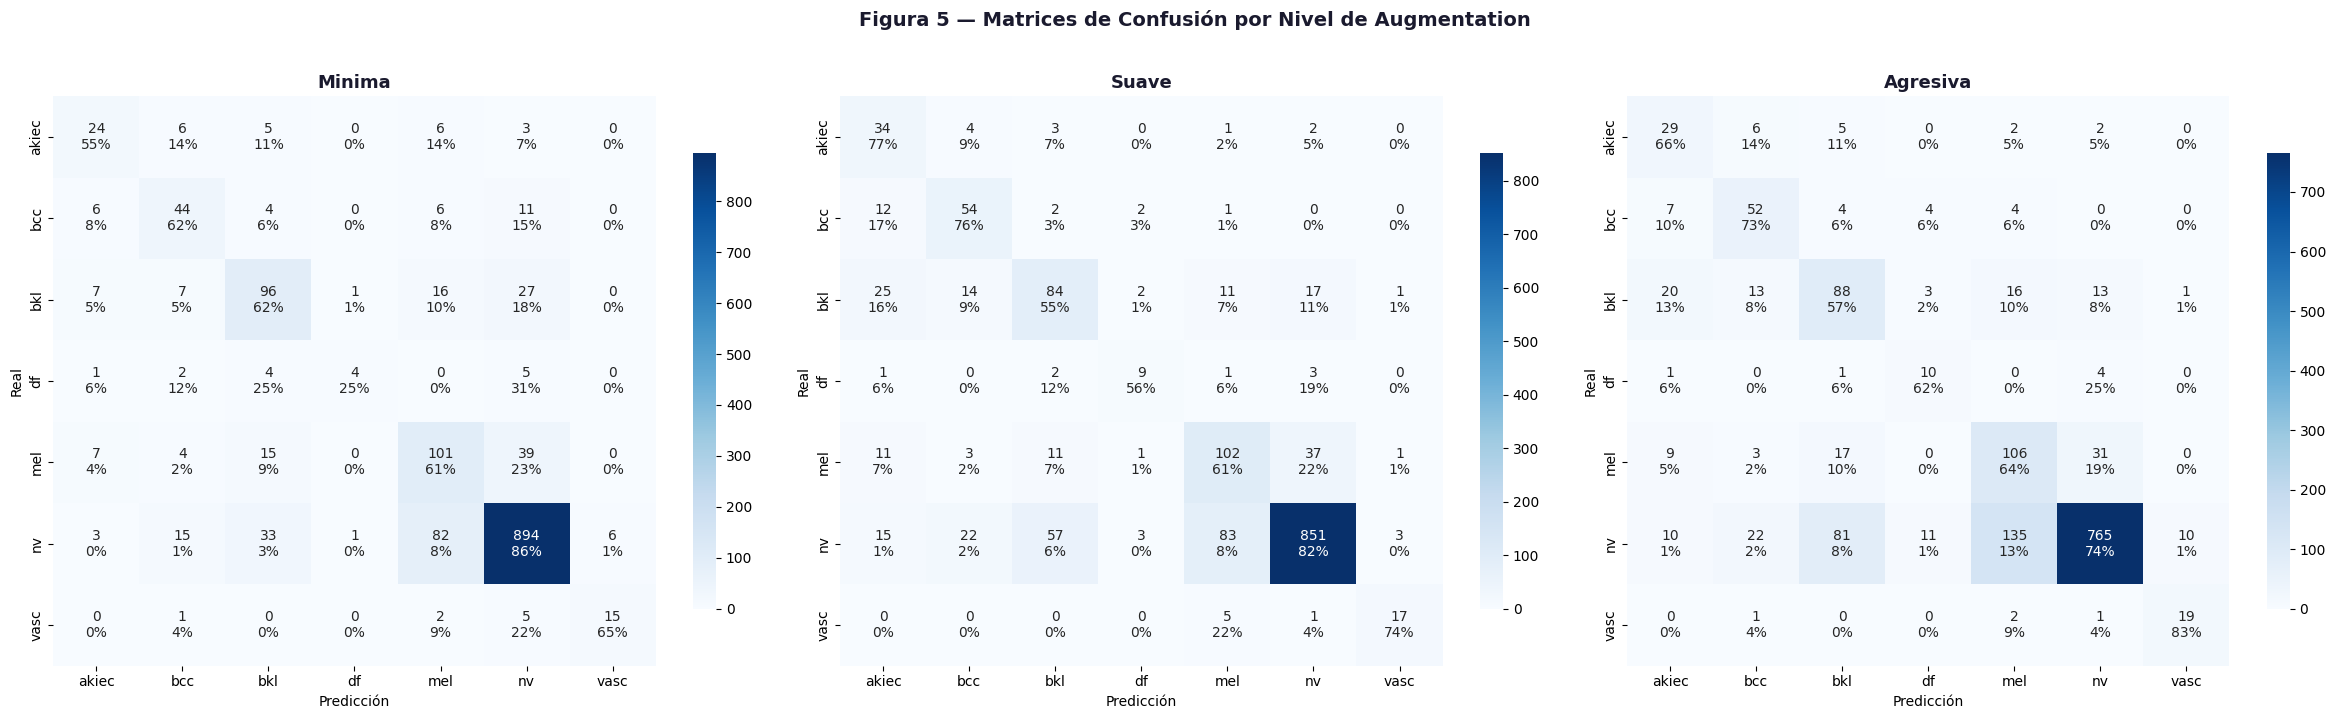

In [17]:
# ============================================
# FIGURA 5: MATRICES DE CONFUSIÓN
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, aug_name in zip(axes, ['minima', 'suave', 'agresiva']):
    labels = results[aug_name]['labels']
    preds = results[aug_name]['preds']
    cm = confusion_matrix(labels, preds)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    annot = np.array([[f'{count}\n{pct:.0f}%' for count, pct in zip(row_c, row_p)]
                      for row_c, row_p in zip(cm, cm_pct)])
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
                xticklabels=class_names_sorted, yticklabels=class_names_sorted,
                ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_title(f'{aug_name.capitalize()}', fontweight='bold', color=NAVY, fontsize=13)
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicci\u00f3n')

fig.suptitle('Figura 5 \u2014 Matrices de Confusi\u00f3n por Nivel de Augmentation',
             fontsize=14, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.show()

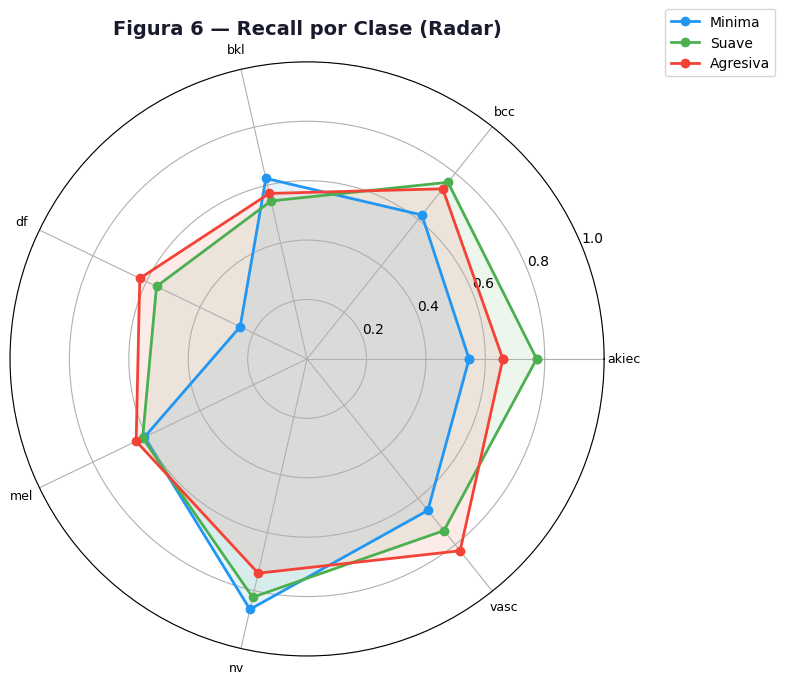

In [18]:
# ============================================
# FIGURA 6: RADAR CHART — RECALL POR CLASE
# ============================================
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

angles = np.linspace(0, 2 * np.pi, len(class_names_sorted), endpoint=False).tolist()
angles += angles[:1]

for aug_name in ['minima', 'suave', 'agresiva']:
    report = results[aug_name]['metrics']['class_report']
    values = [report[cls]['recall'] for cls in class_names_sorted]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=aug_name.capitalize(),
            color=AUG_COLORS[aug_name])
    ax.fill(angles, values, alpha=0.1, color=AUG_COLORS[aug_name])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(class_names_sorted, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title('Figura 6 \u2014 Recall por Clase (Radar)',
             fontweight='bold', color=NAVY, fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

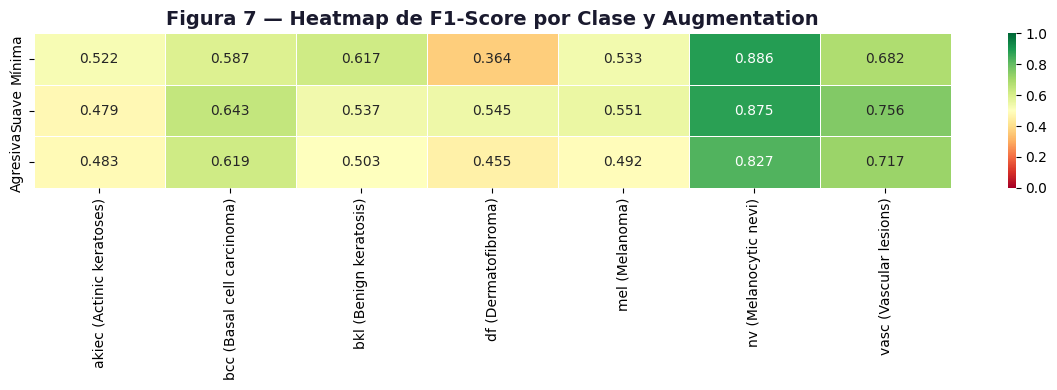

In [19]:
# ============================================
# FIGURA 7: HEATMAP RESUMEN — F1 POR CLASE
# ============================================
data_heatmap = []
for aug_name in ['minima', 'suave', 'agresiva']:
    report = results[aug_name]['metrics']['class_report']
    row = [report[cls]['f1-score'] for cls in class_names_sorted]
    data_heatmap.append(row)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(data_heatmap, annot=True, fmt='.3f', cmap='RdYlGn',
            xticklabels=[f'{c} ({CLASS_NAMES[c]})' for c in class_names_sorted],
            yticklabels=['M\u00ednima', 'Suave', 'Agresiva'],
            ax=ax, vmin=0, vmax=1, linewidths=0.5)
ax.set_title('Figura 7 \u2014 Heatmap de F1-Score por Clase y Augmentation',
             fontweight='bold', color=NAVY, fontsize=14)
plt.tight_layout()
plt.show()

---
## 9. Análisis de Melanoma (relevancia clínica)

In [20]:
# ============================================
# ANÁLISIS ESPECÍFICO DE MELANOMA
# ============================================
mel_idx = class_to_idx['mel']

print('='*60)
print('  AN\u00c1LISIS DE MELANOMA')
print('  (La clase m\u00e1s cr\u00edtica cl\u00ednicamente)')
print('='*60)
print(f'\n{"Augmentation":<15} {"Precision":>10} {"Recall":>10} {"F1":>10} {"Falsos Neg":>12}')
print('-' * 60)

for aug_name in ['minima', 'suave', 'agresiva']:
    report = results[aug_name]['metrics']['class_report']
    labels = results[aug_name]['labels']
    preds = results[aug_name]['preds']
    cm = confusion_matrix(labels, preds)
    mel_fn = cm[mel_idx].sum() - cm[mel_idx, mel_idx]
    mel_total = cm[mel_idx].sum()
    print(f'{aug_name.capitalize():<15} '
          f'{report["mel"]["precision"]:>10.3f} '
          f'{report["mel"]["recall"]:>10.3f} '
          f'{report["mel"]["f1-score"]:>10.3f} '
          f'{mel_fn:>8}/{mel_total}')

print(f'\nFalsos Negativos = melanomas NO detectados (menor es mejor)')
print(f'En contexto cl\u00ednico, un melanoma no detectado puede ser mortal.')

  ANÁLISIS DE MELANOMA
  (La clase más crítica clínicamente)

Augmentation     Precision     Recall         F1   Falsos Neg
------------------------------------------------------------
Minima               0.474      0.608      0.533       65/166
Suave                0.500      0.614      0.551       64/166
Agresiva             0.400      0.639      0.492       60/166

Falsos Negativos = melanomas NO detectados (menor es mejor)
En contexto clínico, un melanoma no detectado puede ser mortal.


---
## 10. Resumen y Conclusiones

In [21]:
# ============================================
# RESUMEN FINAL
# ============================================
print('='*60)
print('  RESUMEN DEL ESTUDIO DE ABLACI\u00d3N')
print('='*60)

best_acc = max(results, key=lambda x: results[x]['metrics']['accuracy'])
best_f1 = max(results, key=lambda x: results[x]['metrics']['f1_macro'])
best_mel = max(results, key=lambda x: results[x]['metrics']['class_report']['mel']['recall'])

print(f'\nMejor Accuracy:        {best_acc.capitalize()} ({results[best_acc]["metrics"]["accuracy"]:.4f})')
print(f'Mejor F1 Macro:        {best_f1.capitalize()} ({results[best_f1]["metrics"]["f1_macro"]:.4f})')
print(f'Mejor Recall Melanoma: {best_mel.capitalize()} ({results[best_mel]["metrics"]["class_report"]["mel"]["recall"]:.4f})')

print(f'\n--- Detalle por nivel ---')
for aug_name in ['minima', 'suave', 'agresiva']:
    m = results[aug_name]['metrics']
    r = m['class_report']
    print(f'\n  {aug_name.capitalize()}:')
    print(f'    Accuracy: {m["accuracy"]:.4f}  |  F1 Macro: {m["f1_macro"]:.4f}  |  AUC: {m["auc_roc"]:.4f}')
    print(f'    Mel Recall: {r["mel"]["recall"]:.4f}  |  Mel F1: {r["mel"]["f1-score"]:.4f}')

  RESUMEN DEL ESTUDIO DE ABLACIÓN

Mejor Accuracy:        Minima (0.7812)
Mejor F1 Macro:        Suave (0.6266)
Mejor Recall Melanoma: Agresiva (0.6386)

--- Detalle por nivel ---

  Minima:
    Accuracy: 0.7812  |  F1 Macro: 0.5986  |  AUC: 0.9324
    Mel Recall: 0.6084  |  Mel F1: 0.5330

  Suave:
    Accuracy: 0.7633  |  F1 Macro: 0.6266  |  AUC: 0.9240
    Mel Recall: 0.6145  |  Mel F1: 0.5514

  Agresiva:
    Accuracy: 0.7089  |  F1 Macro: 0.5851  |  AUC: 0.9146
    Mel Recall: 0.6386  |  Mel F1: 0.4919
